Project title - Parkinson's Disease Detection using Deep Learning

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving parkinsons+telemonitoring (1).zip to parkinsons+telemonitoring (1).zip


Extract ZIP Dataset

In [3]:
for file in os.listdir():

    if file.endswith(".zip"):

        with zipfile.ZipFile(file,'r') as zip_ref:
            zip_ref.extractall()

        print("Dataset extracted")

Dataset extracted


Load Dataset

In [4]:
data = pd.read_csv("parkinsons_updrs.data")

print(data.head())

print("Dataset Shape:", data.shape)

   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181       0.00734   
3     0.000027     0.00191      0.00264  ...        0.327       0.01106   
4     0.000020     0.00093      0.00130  ...        0.176       0.00679   

   Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE  \
0       0.01309        0.01662      

Check Dataset Columns

In [5]:
print(data.columns)

Index(['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
       'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
       'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')


Create Target Column

In [6]:
data["target"] = (data["motor_UPDRS"] > data["motor_UPDRS"].median()).astype(int)

print(data.head())

   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer:APQ3  Shimmer:APQ5  \
0     0.000034     0.00401      0.00317  ...       0.01438       0.01309   
1     0.000017     0.00132      0.00150  ...       0.00994       0.01072   
2     0.000025     0.00205      0.00208  ...       0.00734       0.00844   
3     0.000027     0.00191      0.00264  ...       0.01106       0.01265   
4     0.000020     0.00093      0.00130  ...       0.00679       0.00929   

   Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE      DFA      PPE  \
0        0.01662      0.04

Feature Importance Visualization

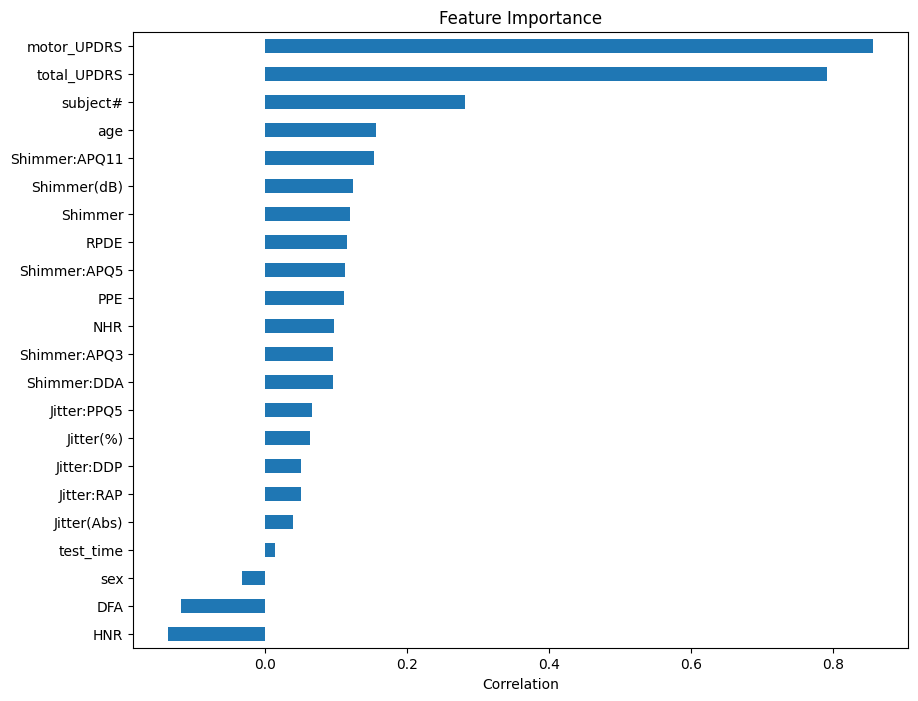

In [7]:
correlation = data.corr()

feature_importance = correlation["target"].drop("target")

feature_importance = feature_importance.sort_values()

plt.figure(figsize=(10,8))

feature_importance.plot(kind="barh")

plt.title("Feature Importance")

plt.xlabel("Correlation")

plt.show()

Separate Features and Target

In [8]:
X = data.drop(["subject#","motor_UPDRS","total_UPDRS","target"],axis=1)

y = data["target"]

Train Test Split

In [9]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

Feature Scaling

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Build Deep Learning Model

In [11]:
model = Sequential()

model.add(Dense(128,activation="relu",input_shape=(X_train.shape[1],)))

model.add(Dense(64,activation="relu"))

model.add(Dense(32,activation="relu"))

model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [12]:
model.compile(

    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]

)

Train Model

In [14]:
history = model.fit(

    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test,y_test)

)

Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9552 - loss: 0.1151 - val_accuracy: 0.9174 - val_loss: 0.2016
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9565 - loss: 0.1062 - val_accuracy: 0.9149 - val_loss: 0.2014
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9599 - loss: 0.1024 - val_accuracy: 0.9149 - val_loss: 0.2155
Epoch 4/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9569 - loss: 0.1089 - val_accuracy: 0.9106 - val_loss: 0.2170
Epoch 5/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9581 - loss: 0.1002 - val_accuracy: 0.9157 - val_loss: 0.1971
Epoch 6/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9690 - loss: 0.0786 - val_accuracy: 0.9191 - val_loss: 0.2007
Epoch 7/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9651 - loss: 0.0874 - val_accuracy: 0.9123 - val_loss: 0.2161
Epoch 8/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9576 - loss: 0.1005 - val_accuracy: 0.

Accuracy & Loss Graphs

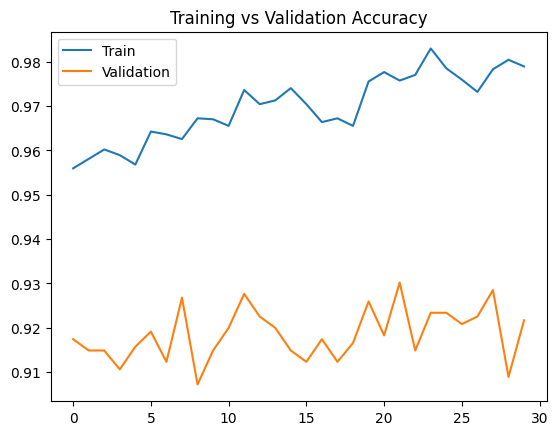

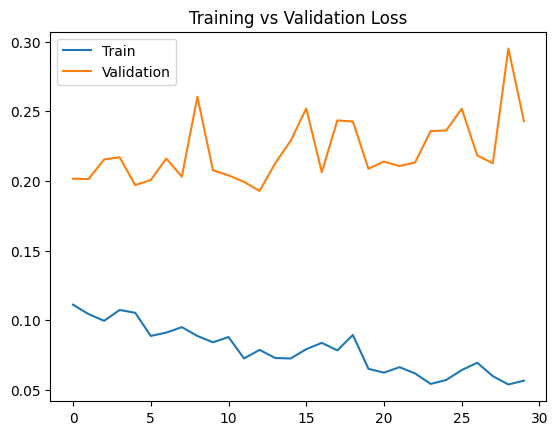

In [15]:
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.legend(["Train","Validation"])

plt.show()


plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.legend(["Train","Validation"])

plt.show()

Model Evaluation

In [17]:
loss,accuracy=model.evaluate(X_test,y_test)

print("Model Accuracy:",accuracy)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9405 - loss: 0.1917
Model Accuracy: 0.9217021465301514


Predictions

In [18]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Confusion Matrix

In [19]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[574  19]
 [ 73 509]]


Confusion Matrix Heatmap

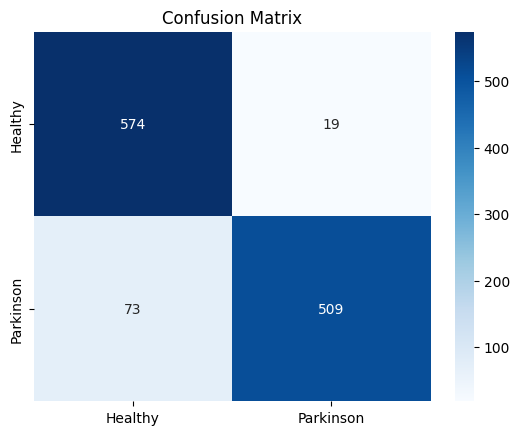

In [21]:
plt.figure()

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Healthy","Parkinson"],
            yticklabels=["Healthy","Parkinson"])

plt.title("Confusion Matrix")

plt.show()

Classification Report

In [22]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       593
           1       0.96      0.87      0.92       582

    accuracy                           0.92      1175
   macro avg       0.93      0.92      0.92      1175
weighted avg       0.93      0.92      0.92      1175



ROC AUC Curve

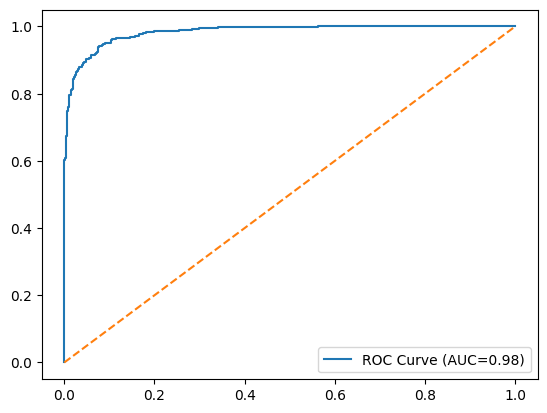

In [23]:
fpr,tpr,thresholds = roc_curve(y_test,y_pred_prob)

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="ROC Curve (AUC=%0.2f)"%roc_auc)

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.show()

Manual Prediction System

In [24]:
# Make sure 'subject#' column exists in your dataset
print("Manual Prediction by Subject#")

# Ask for subject# as input
subject_id = int(input("Enter subject#: "))

# Find the row corresponding to the subject#
row = data[data['subject#'] == subject_id]

if row.empty:
    print("Subject# not found in dataset!")
else:
    # Select feature columns only (exclude motor_UPDRS, total_UPDRS, target, and subject#)
    feature_cols = [col for col in data.columns if col not in ['subject#','motor_UPDRS','total_UPDRS','target']]

    manual_input = row[feature_cols].values  # Convert to array
    manual_input = scaler.transform(manual_input)  # Scale features

    prediction = model.predict(manual_input)

    if prediction[0][0] > 0.5:
        print(f"Prediction for subject# {subject_id}: Parkinson Detected")
    else:
        print(f"Prediction for subject# {subject_id}: Healthy")

Manual Prediction by Subject#
Enter subject#: 2
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Prediction for subject# 2: Healthy


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
